# Retrain with Full CPI Overlap (2017–2023)

The v2 model was trained on a small window (mid-2017 to 2019, ~58 rows).

Now we retrain on the full overlap between maize price data and CPI:
- **Train**: July 2017 to December 2023
- **Test**: January 2024 to April 2025 (16 months of recent, post-COVID data)

This gives the model a much larger training set while keeping an honest holdout
for benchmarking we can publish.


In [ ]:
import pandas as pd
from huggingface_hub import hf_hub_download

# Download datasets from HuggingFace
prices_path = hf_hub_download(
    repo_id="byabasaija/uganda-maize-prices",
    filename="uganda_maize_prices_owino.csv",
    repo_type="dataset",
)
cpi_path = hf_hub_download(
    repo_id="byabasaija/uganda-food-cpi",
    filename="food_cpi_monthly.csv",
    repo_type="dataset",
)

maize_df = pd.read_csv(prices_path)
cpi_df = pd.read_csv(cpi_path)

# Merge on year + month
merged_clean = maize_df.merge(cpi_df, on=["year", "month"], how="inner")
merged_clean["date"] = pd.to_datetime(merged_clean[["year", "month"]].assign(day=15))

print(f"Rows after merge: {len(merged_clean)}")
print(f"Date range: {merged_clean['date'].min().date()} to {merged_clean['date'].max().date()}")
merged_clean[["date", "price", "food_cpi"]].head()

## Build Feature Matrix

In [2]:
import sys
sys.path.insert(0, "../food_prices_api")
from features import compute_features

prices_series = merged["price"].tolist()
feature_rows = []
targets = []

for i in range(6, len(merged)):
    past_prices = prices_series[i - 6 : i]
    row = merged.iloc[i]
    feats = compute_features(past_prices, int(row["month"]), int(row["year"]))
    feats["food_cpi"] = row["food_cpi"]
    feature_rows.append(feats)
    targets.append(prices_series[i])

FEATURE_COLS = [
    "price_lag_1", "price_lag_2", "price_lag_3",
    "rolling_mean_3", "rolling_mean_6",
    "month", "year", "food_cpi",
]

X = pd.DataFrame(feature_rows)[FEATURE_COLS]
y = pd.Series(targets)

merged_trimmed = merged.iloc[6:].reset_index(drop=True)

print(f"Feature matrix: {X.shape}")
X.head()


Feature matrix: (167, 8)


,price_lag_1,price_lag_2,price_lag_3,rolling_mean_3,rolling_mean_6,month,year,food_cpi
0,1150.00,1500.00,2617.00,1755.6667,1505.7817,8,2017,104.9649
1,2700.00,1150.00,1500.00,1783.3333,1658.6150,9,2017,106.0877
2,1022.24,2700.00,1150.00,1624.0800,1641.4883,9,2017,106.0877
3,1000.00,1022.24,2700.00,1574.0800,1664.8733,10,2017,106.3810
4,900.00,1000.00,1022.24,974.0800,1378.7067,10,2017,106.3810


## Train/Test Split

Train on July 2017 to December 2023, test on January 2024 to April 2025.


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

train_mask = merged_trimmed["year"] <= 2023
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train)} rows ({merged_trimmed[train_mask]['date'].min().date()} to {merged_trimmed[train_mask]['date'].max().date()})")
print(f"Test:  {len(X_test)} rows ({merged_trimmed[~train_mask]['date'].min().date()} to {merged_trimmed[~train_mask]['date'].max().date()})")


Train: 143 rows (2017-08-15 to 2023-12-15)
Test:  24 rows (2024-01-15 to 2025-04-15)


## Train and Evaluate


In [4]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:,.0f} UGX/kg")
print(f"R²  : {r2:.4f}")


MAE : 744 UGX/kg
R²  : -5.5788


Actual prices in test set:
count      24.00000
mean     2047.87500
std       325.39532
min      1500.00000
25%      1864.50000
50%      2000.00000
75%      2281.25000
max      2750.00000
dtype: float64

Predicted prices:
count      24.000000
mean     2792.124652
std       236.281334
min      2343.672450
25%      2644.136337
50%      2744.836950
75%      3024.771600
max      3161.926150
dtype: float64


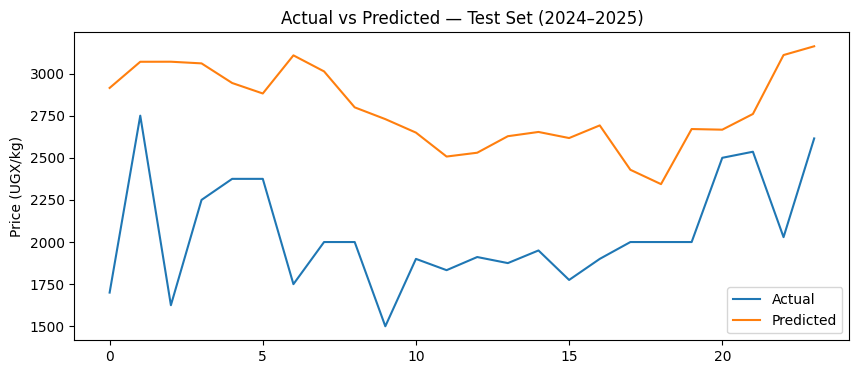

In [6]:
import matplotlib.pyplot as plt

print("Actual prices in test set:")
print(y_test.describe())
print("\nPredicted prices:")
print(pd.Series(y_pred).describe())

plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted — Test Set (2024–2025)")
plt.ylabel("Price (UGX/kg)")
plt.show()


In [7]:
# Retrain without the year feature
FEATURE_COLS_NO_YEAR = [
    "price_lag_1", "price_lag_2", "price_lag_3",
    "rolling_mean_3", "rolling_mean_6",
    "month", "food_cpi",
]

model_no_year = RandomForestRegressor(n_estimators=200, random_state=42)
model_no_year.fit(X_train[FEATURE_COLS_NO_YEAR], y_train)
y_pred_no_year = model_no_year.predict(X_test[FEATURE_COLS_NO_YEAR])

print(f"MAE (no year): {mean_absolute_error(y_test, y_pred_no_year):,.0f} UGX/kg")
print(f"R²  (no year): {r2_score(y_test, y_pred_no_year):.4f}")


MAE (no year): 706 UGX/kg
R²  (no year): -5.1352


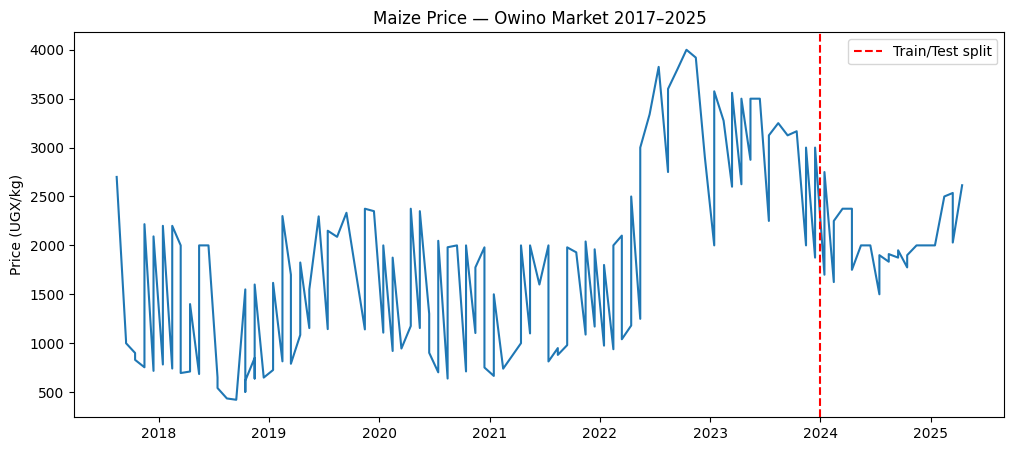

          date   price
137 2023-09-15  3125.0
138 2023-10-15  3167.0
139 2023-11-15  2000.0
140 2023-11-15  3000.0
141 2023-12-15  1875.0
142 2023-12-15  3000.0
143 2024-01-15  1700.0
144 2024-01-15  2750.0
145 2024-02-15  1625.0
146 2024-02-15  2250.0
147 2024-03-15  2375.0
148 2024-04-15  2375.0
149 2024-04-15  1750.0
150 2024-05-15  2000.0
151 2024-06-15  2000.0
152 2024-07-15  1500.0
153 2024-07-15  1900.0
154 2024-08-15  1833.0
155 2024-08-15  1911.0
156 2024-09-15  1875.0
157 2024-09-15  1950.0
158 2024-10-15  1775.0
159 2024-10-15  1900.0
160 2024-11-15  2000.0
161 2024-12-15  2000.0
162 2025-01-15  2000.0
163 2025-02-15  2500.0
164 2025-03-15  2536.0
165 2025-03-15  2029.0
166 2025-04-15  2615.0


In [8]:
plt.figure(figsize=(12, 5))
plt.plot(merged_trimmed["date"], merged_trimmed["price"])
plt.axvline(pd.Timestamp("2024-01-01"), color="red", linestyle="--", label="Train/Test split")
plt.title("Maize Price — Owino Market 2017–2025")
plt.ylabel("Price (UGX/kg)")
plt.legend()
plt.show()

# Also print prices around the split boundary
print(merged_trimmed[["date", "price"]].tail(30).to_string())


In [9]:
dupes = merged_trimmed[merged_trimmed.duplicated(subset=["date"], keep=False)]
print(dupes[["date", "price", "pricetype", "priceflag"]].to_string())


          date    price  pricetype priceflag
1   2017-09-15  1022.24  Wholesale    actual
2   2017-09-15  1000.00     Retail    actual
3   2017-10-15   900.00     Retail    actual
4   2017-10-15   829.48  Wholesale    actual
5   2017-11-15   753.74  Wholesale    actual
6   2017-11-15  2217.00     Retail    actual
7   2017-12-15   717.00  Wholesale    actual
8   2017-12-15  2092.00     Retail    actual
9   2018-01-15   782.15  Wholesale    actual
10  2018-01-15  2200.00     Retail    actual
11  2018-02-15   740.88  Wholesale    actual
12  2018-02-15  1400.00     Retail    actual
13  2018-02-15  2200.00     Retail    actual
14  2018-03-15  2000.00     Retail    actual
15  2018-03-15  1500.00     Retail    actual
16  2018-03-15   694.92  Wholesale    actual
17  2018-04-15   710.44  Wholesale    actual
18  2018-04-15  1400.00     Retail    actual
19  2018-05-15   684.77  Wholesale    actual
20  2018-05-15  1400.00     Retail    actual
21  2018-05-15  2000.00     Retail    actual
23  2018-0

In [10]:
print("Price type counts:")
print(maize_df["pricetype"].value_counts())
print(f"\nTotal rows before dedup: {len(merged_trimmed)}")


Price type counts:
pricetype
Retail       306
Wholesale    133
Name: count, dtype: int64

Total rows before dedup: 167


In [11]:
maize_retail = maize_df[maize_df["pricetype"] == "Retail"].copy()
maize_retail = (
    maize_retail.groupby(["year", "month"], as_index=False)["price"]
    .mean()
    .sort_values(["year", "month"])
    .reset_index(drop=True)
)

merged_clean = maize_retail.merge(cpi_df, on=["year", "month"], how="inner")
merged_clean["date"] = pd.to_datetime(merged_clean[["year", "month"]].assign(day=15))

print(f"Rows after cleaning: {len(merged_clean)}")
print(f"Date range: {merged_clean['date'].min().date()} to {merged_clean['date'].max().date()}")
merged_clean[["date", "price", "food_cpi"]].head()


Rows after cleaning: 87
Date range: 2017-07-15 to 2025-04-15


,date,price,food_cpi
0,2017-07-15,1841.666667,104.3234
1,2017-08-15,1783.333333,104.9649
2,2017-09-15,1000.000000,106.0877
3,2017-10-15,900.000000,106.3810
4,2017-11-15,2217.000000,105.5663


In [12]:
prices_series = merged_clean["price"].tolist()
feature_rows = []
targets = []

for i in range(6, len(merged_clean)):
    past_prices = prices_series[i - 6 : i]
    row = merged_clean.iloc[i]
    feats = compute_features(past_prices, int(row["month"]), int(row["year"]))
    feats["food_cpi"] = row["food_cpi"]
    feature_rows.append(feats)
    targets.append(prices_series[i])

X = pd.DataFrame(feature_rows)[FEATURE_COLS]
y = pd.Series(targets)
merged_trimmed = merged_clean.iloc[6:].reset_index(drop=True)

train_mask = merged_trimmed["year"] <= 2023
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train)} rows")
print(f"Test:  {len(X_test)} rows")


Train: 65 rows
Test:  16 rows


In [13]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:,.0f} UGX/kg")
print(f"R²  : {r2:.4f}")


MAE : 700 UGX/kg
R²  : -8.8062


In [14]:
print("Actual vs Predicted:")
for actual, pred in zip(y_test.values, y_pred):
    print(f"  Actual: {actual:,.0f}  Predicted: {pred:,.0f}  Diff: {actual-pred:+,.0f}")


Actual vs Predicted:
  Actual: 2,225  Predicted: 2,864  Diff: -639
  Actual: 1,938  Predicted: 2,922  Diff: -985
  Actual: 2,375  Predicted: 2,751  Diff: -376
  Actual: 2,062  Predicted: 2,753  Diff: -690
  Actual: 2,000  Predicted: 2,813  Diff: -813
  Actual: 2,000  Predicted: 2,884  Diff: -884
  Actual: 1,700  Predicted: 2,873  Diff: -1,173
  Actual: 1,872  Predicted: 2,868  Diff: -996
  Actual: 1,912  Predicted: 2,908  Diff: -995
  Actual: 1,838  Predicted: 2,857  Diff: -1,019
  Actual: 2,000  Predicted: 2,576  Diff: -576
  Actual: 2,000  Predicted: 2,494  Diff: -494
  Actual: 2,000  Predicted: 2,694  Diff: -694
  Actual: 2,500  Predicted: 2,706  Diff: -206
  Actual: 2,282  Predicted: 2,776  Diff: -494
  Actual: 2,615  Predicted: 2,775  Diff: -160


In [15]:
# Naive baseline: predict the rolling mean of last 3 prices
naive_pred = X_test["rolling_mean_3"].values
naive_mae = mean_absolute_error(y_test, naive_pred)
naive_r2 = r2_score(y_test, naive_pred)

print(f"Naive (rolling mean 3):   MAE: {naive_mae:,.0f}  R²: {naive_r2:.4f}")
print(f"Random Forest with CPI:   MAE: {mae:,.0f}  R²: {r2:.4f}")


Naive (rolling mean 3):   MAE: 196  R²: -0.0995
Random Forest with CPI:   MAE: 700  R²: -8.8062
